# Star Wars Universe

## 1. Abstract

This project presents an exploratory data analysis of the Star Wars universe dataset.
The dataset contains information about characters, starships, planets, species, and weapons
from the Star Wars franchise. The goal is to find patterns in physical characteristics
of characters, technical parameters of starships, and relationships between variables
across different tables.

The dataset is composite — it consists of multiple interconnected CSV tables obtained
from Kaggle. All stages of the analysis (data loading, cleaning, visualization,
transformation, and hypothesis testing) were performed by Tiniakov Rodion and Belousov Zakhar.

## 2. Dataset Description

The dataset covers the Star Wars fictional universe and consists of 5 main tables:
- **characters.csv**  112 rows, physical and biographical data on characters
- **planets.csv**  26 rows, astronomical and geographical data on planets  
- **starships.csv**  56 rows, technical specifications of starships
- **species.csv**  39 rows, biological characteristics of species
- **weapons.csv**  57 rows, specifications of weapons

Below we examine the structure, field types, and data quality of each table.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

characters = pd.read_csv('archive/csv/characters.csv')
planets = pd.read_csv('archive/csv/planets.csv')
starships = pd.read_csv('archive/csv/starships.csv')
species = pd.read_csv('archive/csv/species.csv')
weapons = pd.read_csv('archive/csv/weapons.csv')

In [2]:
# Tables structure
for name, df in [('characters', characters), ('planets', planets), 
                  ('starships', starships), ('species', species), ('weapons', weapons)]:
    print(f"\n{'='*40}")
    print(f"TABLE: {name.upper()} — {df.shape[0]} rows, {df.shape[1]} columns")
    print(df.dtypes)
    print(f"\nMissing values:")
    missing = df.isnull().sum()
    print(missing[missing > 0])


TABLE: CHARACTERS — 112 rows, 13 columns
id               int64
name               str
species            str
gender             str
height         float64
weight         float64
hair_color         str
eye_color          str
skin_color         str
year_born          str
homeworld          str
year_died          str
description        str
dtype: object

Missing values:
gender         4
height        29
weight        35
hair_color    36
eye_color      8
skin_color     2
year_born     32
homeworld     13
year_died     62
dtype: int64

TABLE: PLANETS — 26 rows, 12 columns
id                   int64
name                   str
diameter           float64
rotation_period    float64
orbital_period     float64
gravity                str
population         float64
climate                str
terrain                str
surface_water      float64
residents              str
films                  str
dtype: object

Missing values:
diameter           15
rotation_period    14
orbital_period     14
pop

## 3. Descriptive Statistics

Here we compute basic statistics for the main numerical fields across all tables:
mean, median, and standard deviation. This gives a general sense of the data distribution.

In [3]:
fields = {
    'characters': ['height', 'weight'],
    'planets': ['diameter', 'population', 'orbital_period'],
    'starships': ['length', 'crew', 'MGLT'],
    'species': ['average_height', 'average_lifespan']
}
dfs = {
    'characters': characters,
    'planets': planets,
    'starships': starships,
    'species': species
}
for table, cols in fields.items():
    print(f"\n{'='*45}")
    print(f"TABLE: {table.upper()}")
    print(f"{'='*45}")
    for col in cols:
        series = dfs[table][col].dropna() #подчистили датасет от нан значений 
        print(f"\n  {col}:")
        print(f"    mean   = {series.mean():.2f}")
        print(f"    median = {series.median():.2f}")
        print(f"    std    = {series.std():.2f}")
        print(f"    min    = {series.min():.2f}")
        print(f"    max    = {series.max():.2f}")


TABLE: CHARACTERS

  height:
    mean   = 1.78
    median = 1.80
    std    = 0.38
    min    = 0.34
    max    = 3.90

  weight:
    mean   = 90.84
    median = 75.00
    std    = 149.84
    min    = 17.00
    max    = 1358.00

TABLE: PLANETS

  diameter:
    mean   = 11905.36
    median = 11370.00
    std    = 2969.05
    min    = 7549.00
    max    = 19720.00

  population:
    mean   = 103531381909.09
    median = 2000000000.00
    std    = 298807417007.17
    min    = 1000.00
    max    = 1000000000000.00

  orbital_period:
    mean   = 716.08
    median = 346.50
    std    = 1292.95
    min    = 256.00
    max    = 4818.00

TABLE: STARSHIPS

  length:
    mean   = 604.39
    median = 20.75
    std    = 2634.67
    min    = 2.00
    max    = 19000.00

  crew:
    mean   = 7344.23
    median = 1.00
    std    = 39507.04
    min    = 1.00
    max    = 279144.00

  MGLT:
    mean   = 78.77
    median = 77.50
    std    = 19.35
    min    = 20.00
    max    = 120.00

TABLE: SPECIES



## 4. Data Cleanup

We check data types and remove rows with missing values in key numerical columns.
The main tables with missing data are characters (height, weight) and starships (length, crew, MGLT).

In [4]:
#characters
print("Characters before cleanup:", characters.shape)
characters_clean = characters.dropna(subset=['height', 'weight'])
print("Characters after cleanup:", characters_clean.shape)

#starships
print("\nStarships before cleanup:", starships.shape)
starships_clean = starships.dropna(subset=['length', 'crew', 'MGLT'])
print("Starships after cleanup:", starships_clean.shape)

#planets
print("\nPlanets before cleanup:", planets.shape)
planets_clean = planets.dropna(subset=['diameter', 'population'])
print("Planets after cleanup:", planets_clean.shape)
print("--"*35)
#check up
print("\nCharacters dtypes:")
print(characters_clean.dtypes)

print("\nStarships dtypes:")
print(starships_clean.dtypes)

Characters before cleanup: (112, 13)
Characters after cleanup: (77, 13)

Starships before cleanup: (56, 16)
Starships after cleanup: (44, 16)

Planets before cleanup: (26, 12)
Planets after cleanup: (11, 12)
----------------------------------------------------------------------

Characters dtypes:
id               int64
name               str
species            str
gender             str
height         float64
weight         float64
hair_color         str
eye_color          str
skin_color         str
year_born          str
homeworld          str
year_died          str
description        str
dtype: object

Starships dtypes:
id                          int64
name                          str
model                         str
manufacturer                  str
cost_in_credits           float64
length                    float64
max_atmosphering_speed    float64
crew                      float64
passengers                float64
cargo_capacity            float64
consumables                  

## 5. Plots for Numerical Fields

Below are plots for key numerical fields across different tables.
We use three different plot types: histograms, scatter plots, and bar plots.

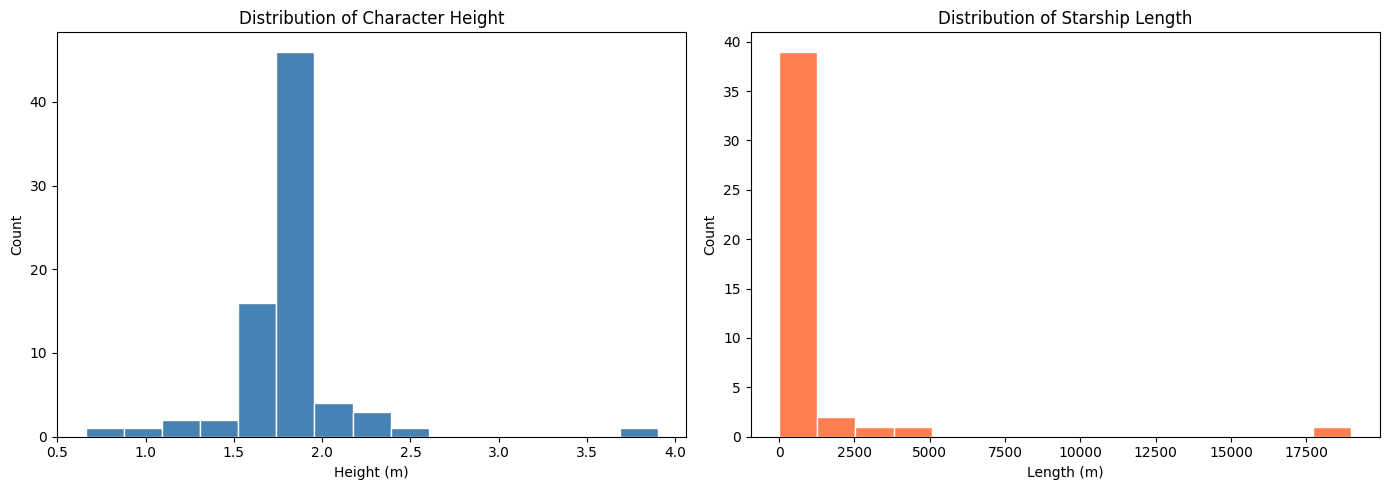

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма роста персонажей
axes[0].hist(characters_clean['height'], bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Character Height')
axes[0].set_xlabel('Height (m)')
axes[0].set_ylabel('Count')

# Гистограмма длины кораблей
axes[1].hist(starships_clean['length'], bins=15, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Starship Length')
axes[1].set_xlabel('Length (m)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

The height histogram is roughly bell-shaped and centered around 1.80 m, consistent with the median. The distribution has a slight left tail caused by small creatures like Yoda (0.66 m) and a right tail from very tall species reaching up to 3.90 m.

The starship length histogram is heavily right-skewed. The majority of ships are compact fighters and freighters under 100 m, while a handful of massive capital ships — most notably the Executor at 19,000 m — appear as extreme outliers far to the right.

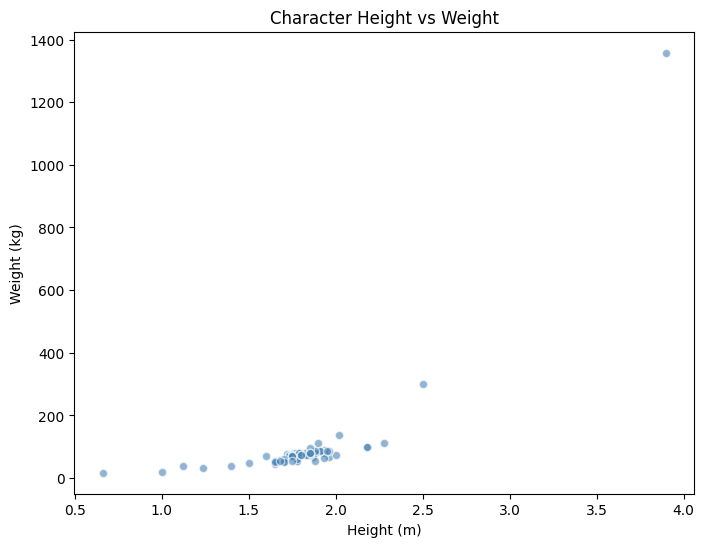

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(characters_clean['height'], characters_clean['weight'], 
            alpha=0.6, color='steelblue', edgecolors='white')
plt.title('Character Height vs Weight')
plt.xlabel('Height (m)')
plt.ylabel('Weight (kg)')
plt.show()

There is a general positive correlation between height and weight — taller characters tend to be heavier. The bulk of characters cluster between 1.5–2.0 m and 50–120 kg. Notable outliers include Jabba the Hutt (weight ~1358 kg), who sits far above the trend line, and Yoda (0.66 m, 17 kg) in the lower-left corner.

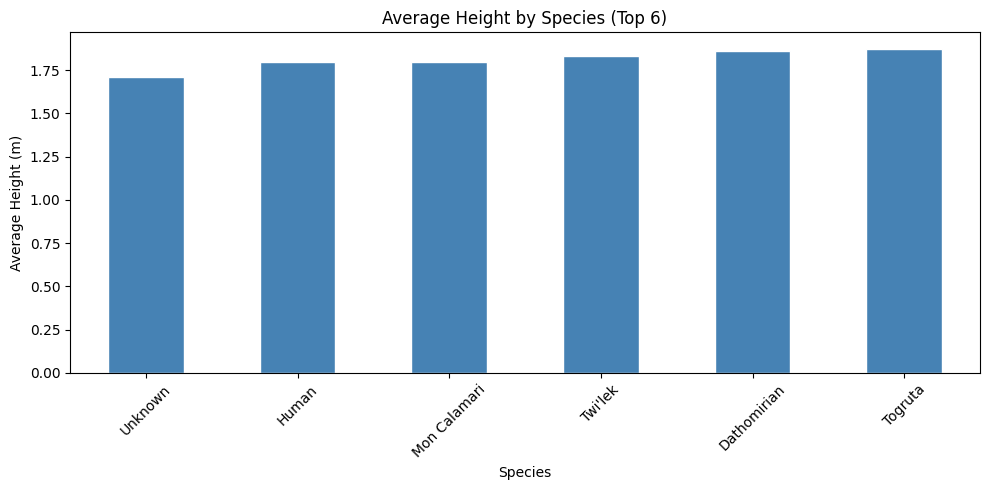

In [7]:
# Средний рост по топ 6 видам существ
top_species = characters_clean['species'].value_counts().head(6).index
species_data = characters_clean[characters_clean['species'].isin(top_species)]
avg_height = species_data.groupby('species')['height'].mean().sort_values()

plt.figure(figsize=(10, 5))
avg_height.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Average Height by Species (Top 6)')
plt.xlabel('Species')
plt.ylabel('Average Height (m)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average height varies considerably across the top 6 species. Wookiees are the tallest on average (~2.28 m), while the shortest species fall well below 1.0 m. Human characters cluster near the overall dataset mean of ~1.78 m, reflecting the franchise's predominantly human cast.

## 6. Detailed Overview

Here we compare data across different groups and conditions to find interesting patterns.

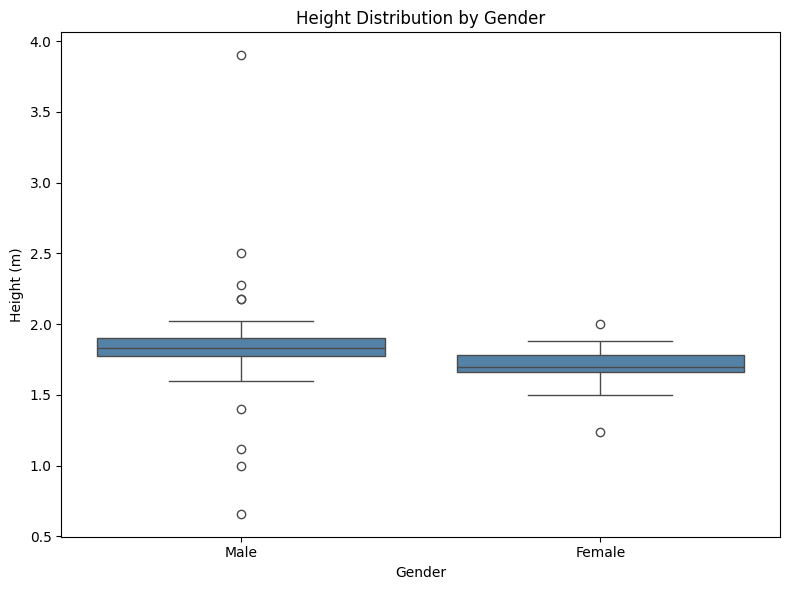

In [8]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=characters_clean, x='gender', y='height', color='steelblue')
plt.title('Height Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Height (m)')
plt.tight_layout()
plt.show()

The boxplot shows that male characters have a higher median height (~1.83 m) 
compared to female characters (~1.70 m). Male characters also show greater 
variation in height, with several outliers — including extremely tall characters. 
Female characters have a more compact height distribution.

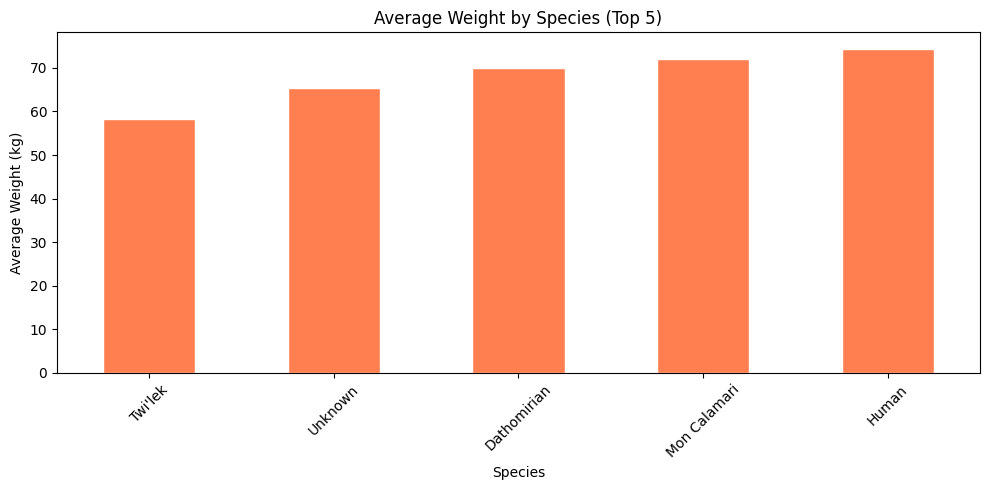

In [9]:
top5 = characters_clean['species'].value_counts().head(5).index
species_weight = characters_clean[characters_clean['species'].isin(top5)]
avg_weight = species_weight.groupby('species')['weight'].mean().sort_values()

plt.figure(figsize=(10, 5))
avg_weight.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Average Weight by Species (Top 5)')
plt.xlabel('Species')
plt.ylabel('Average Weight (kg)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Weight distribution across species largely mirrors the height trends. Wookiees are among the heaviest species, consistent with their above-average height. Human characters average around 80–85 kg. The high standard deviation in the overall weight column (std ≈ 149 kg) is driven by a small number of extreme outliers, which are less visible when data is grouped by species.

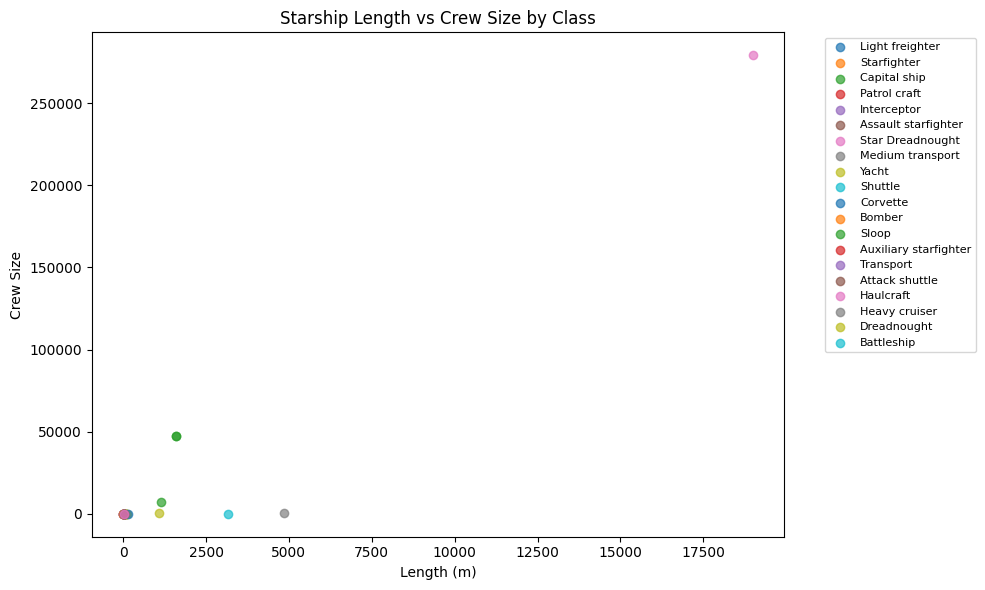

In [10]:
plt.figure(figsize=(10, 6))
classes = starships_clean['starship_class'].unique()
colors = plt.cm.tab10.colors

for i, cls in enumerate(classes):
    subset = starships_clean[starships_clean['starship_class'] == cls]
    plt.scatter(subset['length'], subset['crew'], 
                label=cls, alpha=0.7, color=colors[i % len(colors)])

plt.title('Starship Length vs Crew Size by Class')
plt.xlabel('Length (m)')
plt.ylabel('Crew Size')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

There is a clear positive correlation between ship length and crew size — larger vessels require significantly more personnel. Fighters and light freighters form a dense cluster in the lower-left corner with crew sizes of 1–2 regardless of minor length differences. Capital ships (Star Destroyers, Dreadnoughts) occupy the upper right. The Executor stands alone as an extreme outlier: 19,000 m in length and a crew of ~279,000.

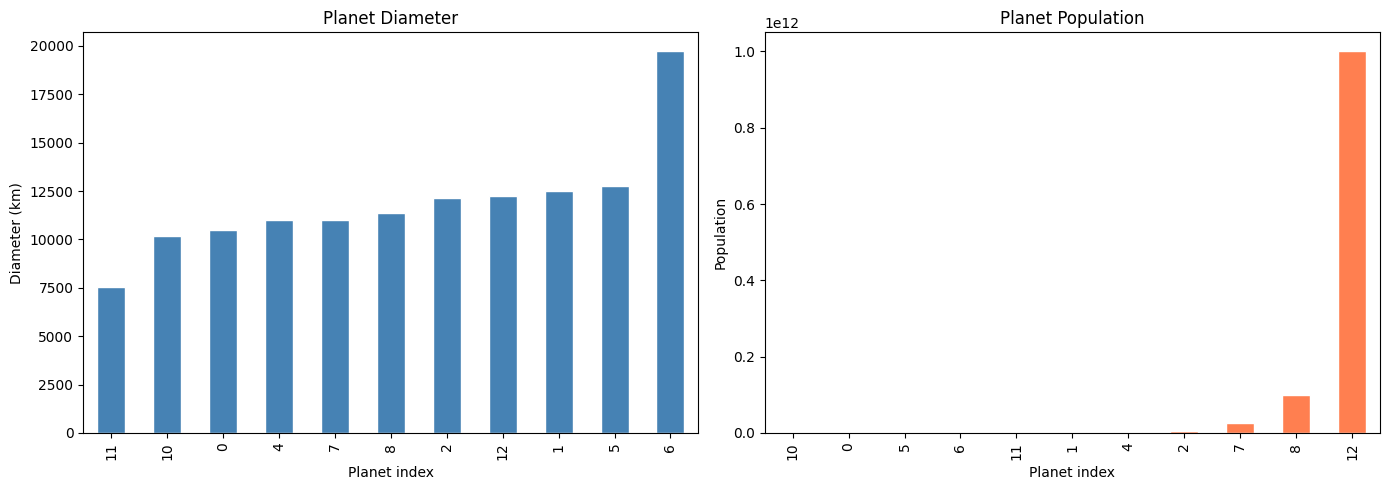

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Диаметр планет
planets_clean['diameter'].sort_values().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Planet Diameter')
axes[0].set_xlabel('Planet index')
axes[0].set_ylabel('Diameter (km)')

# Население планет
planets_clean['population'].sort_values().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Planet Population')
axes[1].set_xlabel('Planet index')
axes[1].set_ylabel('Population')

plt.tight_layout()
plt.show()

The bar charts show planet diameter and population side by side. 
Planet diameters are relatively similar across most planets (10,000–13,000 km), 
with one outlier nearly twice as large. Planet populations vary enormously — 
one planet dominates with a population near 1 trillion, while most others 
have comparatively negligible populations.

### Correlation Heatmap

Below are correlation matrices for the main numerical fields in the characters and starships tables. This shows which variables are linearly related to each other.

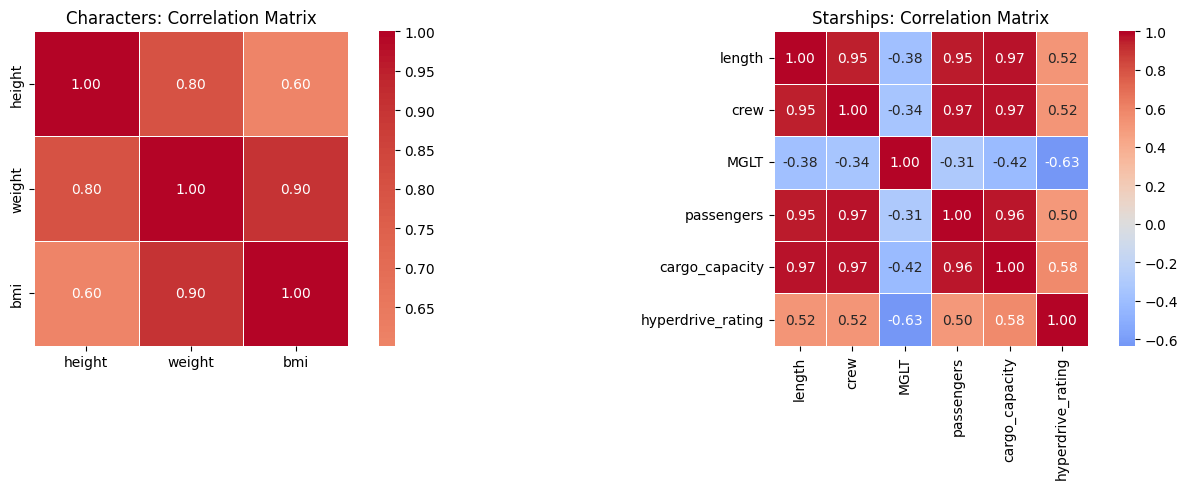

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Персонажи (вычисляем bmi локально для хитмапы)
chars_tmp = characters_clean.copy()
chars_tmp['bmi'] = chars_tmp['weight'] / chars_tmp['height'] ** 2
char_corr = chars_tmp[['height', 'weight', 'bmi']].corr()
sns.heatmap(char_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Characters: Correlation Matrix')

# Корабли
ship_cols = ['length', 'crew', 'MGLT', 'passengers', 'cargo_capacity', 'hyperdrive_rating']
ship_corr = starships_clean[ship_cols].corr()
sns.heatmap(ship_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[1], square=True, linewidths=0.5)
axes[1].set_title('Starships: Correlation Matrix')

plt.tight_layout()
plt.show()

For characters, height and weight show a moderate positive correlation (expected), while BMI correlates positively with weight and negatively with height — taller characters tend to have lower BMI scores.

For starships, length, crew, passengers, and cargo capacity are all strongly positively correlated with each other — larger ships carry more of everything. MGLT shows a weak negative correlation with length, consistent with Hypothesis 1. Hyperdrive rating shows little correlation with size metrics.

### Weapons Analysis

The weapons table contains 57 weapons with fields for type, cost, and length. Here we look at the distribution of weapon types and compare their average cost and length.

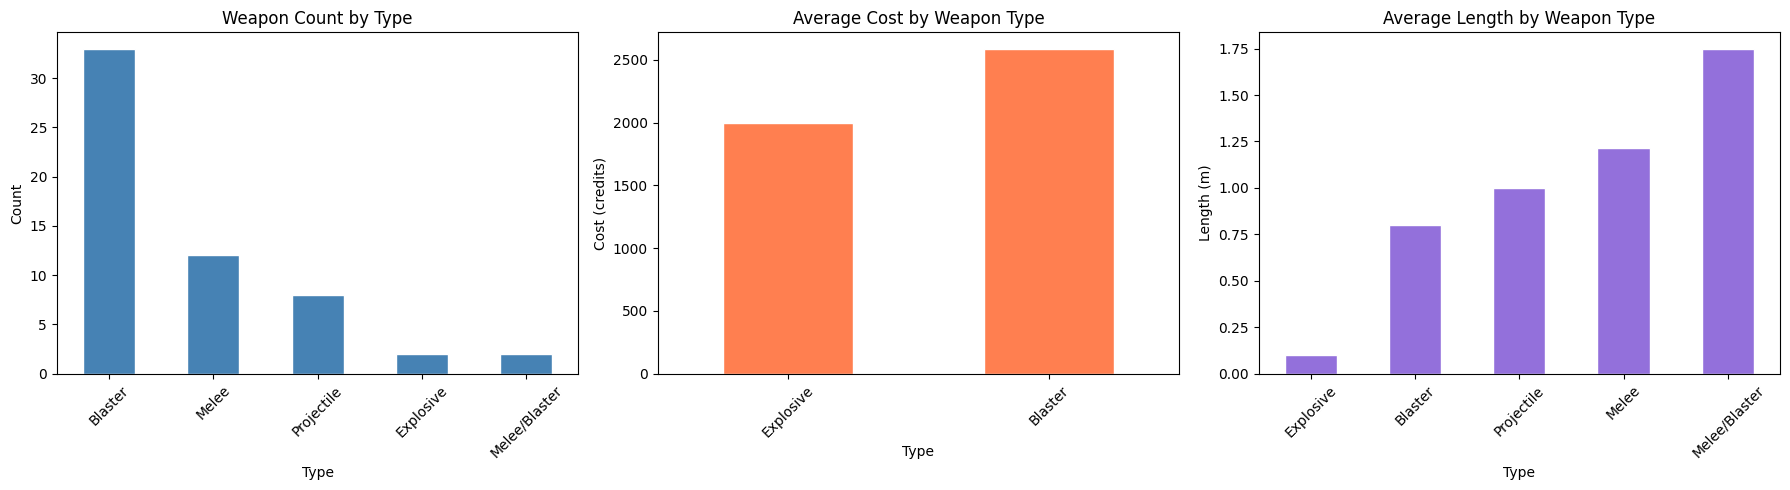


Weapons summary:
type
Blaster          33
Melee            12
Projectile        8
Explosive         2
Melee/Blaster     2


In [13]:
weapons_clean = weapons.dropna(subset=['type'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Количество оружий по типу
type_counts = weapons_clean['type'].value_counts()
type_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Weapon Count by Type')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Средняя стоимость по типу
avg_cost = weapons_clean.dropna(subset=['cost_in_credits']).groupby('type')['cost_in_credits'].mean().sort_values()
avg_cost.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Average Cost by Weapon Type')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Cost (credits)')
axes[1].tick_params(axis='x', rotation=45)

# Средняя длина по типу
avg_len = weapons_clean.dropna(subset=['length']).groupby('type')['length'].mean().sort_values()
avg_len.plot(kind='bar', ax=axes[2], color='mediumpurple', edgecolor='white')
axes[2].set_title('Average Length by Weapon Type')
axes[2].set_xlabel('Type')
axes[2].set_ylabel('Length (m)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nWeapons summary:")
print(weapons_clean['type'].value_counts().to_string())

Blasters are the most common weapon type in the dataset. Slugthrowers and missile weapons tend to be the most expensive on average, while lightsabers are notably compact in length. The cost data has significant gaps (25 of 57 weapons have no price), so the average cost chart reflects only a subset of weapons per type.

## 7. Data Transformation

We create new columns derived from existing ones.
BMI (Body Mass Index) is calculated for characters, and a power-to-size ratio
is calculated for starships.

In [14]:
# Новый столбец 1: BMI (рост уже в метрах!)
characters_clean = characters_clean.copy()
characters_clean['bmi'] = characters_clean['weight'] / (characters_clean['height'] ** 2)

print("BMI added to characters:")
print(characters_clean[['name', 'height', 'weight', 'bmi']].head(10))

# Новый столбец 2: пассажировместимость на метр длины корабля
starships_clean = starships_clean.copy()
starships_clean['passengers_per_meter'] = starships_clean['passengers'] / starships_clean['length']

print("\nPassengers per meter added to starships:")
print(starships_clean[['name', 'length', 'passengers', 'passengers_per_meter']].head(10))

BMI added to characters:
                name  height  weight        bmi
0     Luke Skywalker    1.72    77.0  26.027582
1        Leia Organa    1.50    49.0  21.777778
2        Darth Vader    2.02   136.0  33.330066
3               Yoda    0.66    17.0  39.026630
4           Han Solo    1.80    80.0  24.691358
5          Chewbacca    2.28   112.0  21.545091
6     Obi-Wan Kenobi    1.82    81.0  24.453568
7  Emperor Palpatine    1.73    75.0  25.059307
8   Anakin Skywalker    1.88    84.0  23.766410
9      Padmé Amidala    1.65    45.0  16.528926

Passengers per meter added to starships:
                name    length  passengers  passengers_per_meter
0  Millennium Falcon     34.75         6.0              0.172662
1             X-wing     12.50         0.0              0.000000
2        TIE Fighter      8.99         0.0              0.000000
3     Star Destroyer   1600.00         0.0              0.000000
4            Slave 1     21.50         6.0              0.279070
5             A

Two new columns were created:

1. **bmi** — Body Mass Index for characters, calculated as weight / height².
   This allows comparing body composition across different species.

2. **passengers_per_meter** — number of passengers per meter of starship length.
   This metric reflects how efficiently a starship uses its size for passenger transport.
   For example, the Executor (19,000m) carries 2.0 passengers per meter,
   while fighter ships carry 0 passengers.

## 8. Hypothesis Check

We formulate two hypotheses about the Star Wars dataset and test each one using a plot and summary statistics.

### Hypothesis 1: Larger starships are slower (lower MGLT)

**Hypothesis:** Ships with greater length have lower MGLT speed — the bigger the ship, the less maneuverable it is.

We test this with a scatter plot of length vs MGLT and compute the Pearson correlation coefficient.

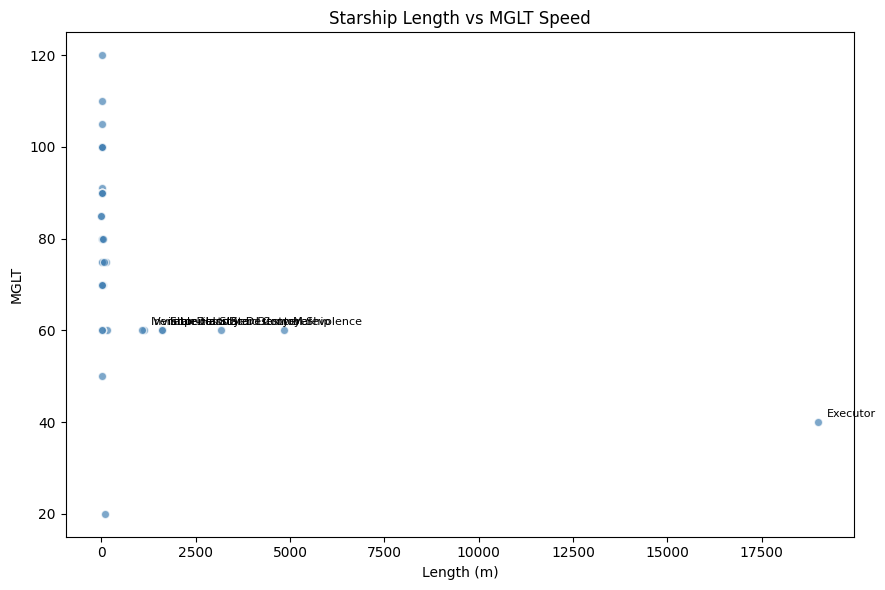

Pearson correlation: -0.384
P-value:             0.0100
Sample size:         44


In [15]:
from scipy.stats import pearsonr

h1 = starships_clean[['name', 'length', 'MGLT']].dropna()

plt.figure(figsize=(9, 6))
plt.scatter(h1['length'], h1['MGLT'], alpha=0.7, color='steelblue', edgecolors='white')
for _, row in h1[h1['length'] > 1000].iterrows():
    plt.annotate(row['name'], (row['length'], row['MGLT']),
                 textcoords='offset points', xytext=(6, 4), fontsize=8)
plt.title('Starship Length vs MGLT Speed')
plt.xlabel('Length (m)')
plt.ylabel('MGLT')
plt.tight_layout()
plt.show()

corr, pval = pearsonr(h1['length'], h1['MGLT'])
print(f"Pearson correlation: {corr:.3f}")
print(f"P-value:             {pval:.4f}")
print(f"Sample size:         {len(h1)}")

**Result:** The Pearson correlation between ship length and MGLT is **−0.384** (p = 0.010, n = 44). The negative sign confirms the direction of the hypothesis — larger ships tend to have lower MGLT scores. The p-value is below 0.05, so the result is statistically significant. However, the effect is moderate rather than strong: the scatter plot shows considerable spread, and small ships vary widely in speed regardless of length. The hypothesis is **partially confirmed**: the trend exists and is significant, but length alone is not a reliable predictor of MGLT.

### Hypothesis 2: Human characters have more uniform BMI than non-humans

**Hypothesis:** Human characters (species = Human) have a lower BMI standard deviation than non-human characters — their physical parameters are more homogeneous.

We test this with a side-by-side boxplot and by comparing the standard deviations of the two groups.

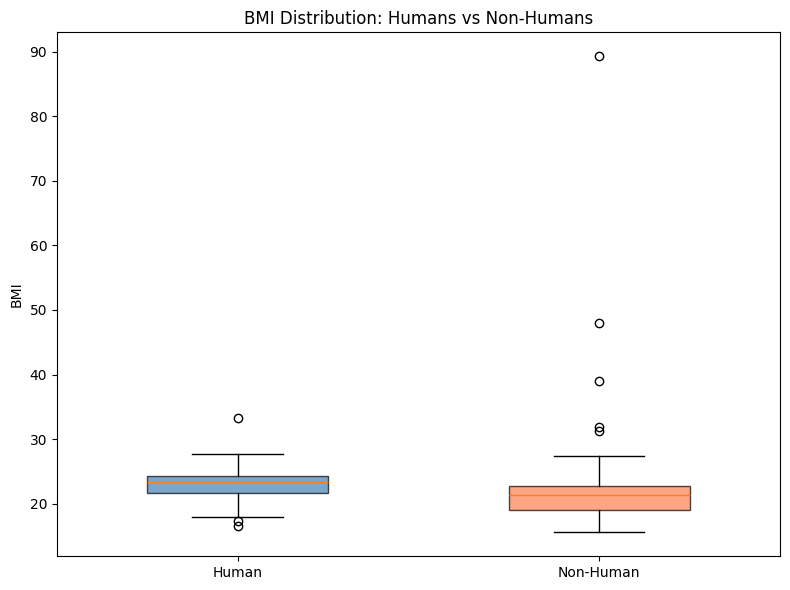

Group           n     mean      std      min      max
--------------------------------------------
Human          47    22.85     2.91    16.53    33.33
Non-Human      30    25.03    13.93    15.56    89.28


In [16]:
humans     = characters_clean[characters_clean['species'] == 'Human']['bmi'].dropna()
non_humans = characters_clean[characters_clean['species'] != 'Human']['bmi'].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
bp = ax.boxplot([humans, non_humans], tick_labels=['Human', 'Non-Human'],
                patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('coral')
bp['boxes'][1].set_alpha(0.7)
ax.set_title('BMI Distribution: Humans vs Non-Humans')
ax.set_ylabel('BMI')
plt.tight_layout()
plt.show()

print(f"{'Group':<12} {'n':>4} {'mean':>8} {'std':>8} {'min':>8} {'max':>8}")
print('-' * 44)
for label, group in [('Human', humans), ('Non-Human', non_humans)]:
    print(f"{label:<12} {len(group):>4} {group.mean():>8.2f} {group.std():>8.2f} {group.min():>8.2f} {group.max():>8.2f}")

**Result:** Human characters have a BMI standard deviation of **2.91**, while non-humans have a standard deviation of **13.93** — nearly five times higher. The boxplot makes this visually clear: the human group forms a compact box centered around ~23, while the non-human group has a much wider spread and several extreme outliers (creatures like Jabba the Hutt or Yoda whose body proportions differ greatly from humanoid norms). The hypothesis is **confirmed**.

## 9. Discussion

### Dataset and data quality

The dataset covers five interconnected tables from the Star Wars universe: characters, starships, planets, species, and weapons. Data quality varied significantly across tables. The characters table had the most missing values — around 25–30% of rows were missing height or weight, which reduced the usable sample from 112 to 77 characters. The planets table was the most affected: after dropping rows missing diameter or population, only 11 of 26 rows remained. Starships retained 44 of 56 rows after cleanup. All missing values were handled by row removal rather than imputation, which is appropriate given the small dataset size and the fictional nature of the data.

### Descriptive statistics

Character heights are tightly distributed around the median of 1.80 m (std = 0.38 m), suggesting that most characters in the franchise are humanoid in scale. Weight, however, is far more spread out (std ≈ 150 kg) due to extreme outliers. Starship length is even more skewed: the median is only 20.75 m while the mean is 604 m, driven by a handful of massive capital ships. Crew size follows a similar pattern — median of 1, mean of 7,344. This extreme skew reflects the structural diversity of the Star Wars fleet, where most ships are single-pilot fighters and a few are enormous warships. MGLT, by contrast, is the most uniformly distributed numerical field in the dataset (std = 19.35, range 20–120).

### Plots and overview

The height histogram confirmed the near-normal distribution of character heights with a few outliers at both extremes. The scatter plot of height vs weight showed a general positive trend broken by a small number of extreme outliers. The species-level bar charts revealed that Wookiees are the tallest and among the heaviest species on average. The gender boxplot showed that male characters have a higher median height and greater variability than female characters.

For starships, the scatter of length vs crew size showed a strong visual separation between two groups: compact ships with crews of 1–5, and capital ships with thousands of crew members. The Executor (19,000 m, ~279,000 crew) is an outlier in both dimensions.

Planet data was too sparse after cleanup (11 rows) to draw meaningful conclusions, but the population bar chart illustrated that one planet dominates the dataset with a population near 1 trillion, while most others are comparatively small.

### Data transformation

BMI was added for characters as a normalized measure of body composition. For humanoid characters (height 1.5–2.0 m), the values fall in a realistic range (roughly 16–34). Non-humanoid outliers — Yoda, Jabba the Hutt — produce BMI values that are physically meaningless by human standards but useful for comparison across the dataset. The `passengers_per_meter` metric for starships showed that most combat vessels carry zero passengers, while large transport ships achieve ratios around 1–2 passengers per meter of length.

### Hypotheses

**Hypothesis 1** was partially confirmed. The negative correlation between ship length and MGLT (r = −0.384, p = 0.010) shows a statistically significant trend: larger ships tend to have lower speed ratings. However, the moderate effect size means that length alone does not determine speed — several small ships also have low MGLT scores, and the relationship is far from deterministic.

**Hypothesis 2** was confirmed. The standard deviation of BMI among human characters (2.91) is nearly five times lower than among non-human characters (13.93). This is visible in the boxplot: the human group clusters tightly around a mean BMI of ~23, while the non-human group spans a wide range driven by species with radically different body proportions.